<a href="https://colab.research.google.com/github/AkankshaB123/python/blob/main/Positive_uplift_scatterplot_plotline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [57]:
df = pd.read_csv("/content/sample_data/Case_Study_Urgency_Message_Data.xlsx - Aggregated.csv", low_memory=False)

In [33]:
df.head(2)

,#,ADR_USD,hotel_id,city_id,City,star_rating,accommadation_type_name,chain_hotel,booking_date,checkin_date,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47
0,1,71.06,"297,388","9,395",City_A,2.5,Hotel,non-chain,8/2/2016,10/1/2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,76.56,"298,322","9,395",City_A,3.0,Hotel,non-chain,8/2/2016,10/1/2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
df.loc[df['city_id'] == '16,808', 'City'].value_counts()

,count
City,
City_D,10107


Group: City_A - Hostel, Cleaned Data points: 1002
  x min: 0, x max: 60, x unique count: 61
Group: City_A - Ryokan, Cleaned Data points: 9
  x min: 0, x max: 10, x unique count: 8
Group: City_B - Resort, Cleaned Data points: 1905
  x min: 0, x max: 60, x unique count: 61
Group: City_C - Guest House / Bed & Breakfast, Cleaned Data points: 374
  x min: 0, x max: 60, x unique count: 58
Group: City_D - Hotel, Cleaned Data points: 7733
  x min: 0, x max: 60, x unique count: 61
Group: City_E - Serviced Apartment, Cleaned Data points: 302
  x min: 0, x max: 60, x unique count: 50


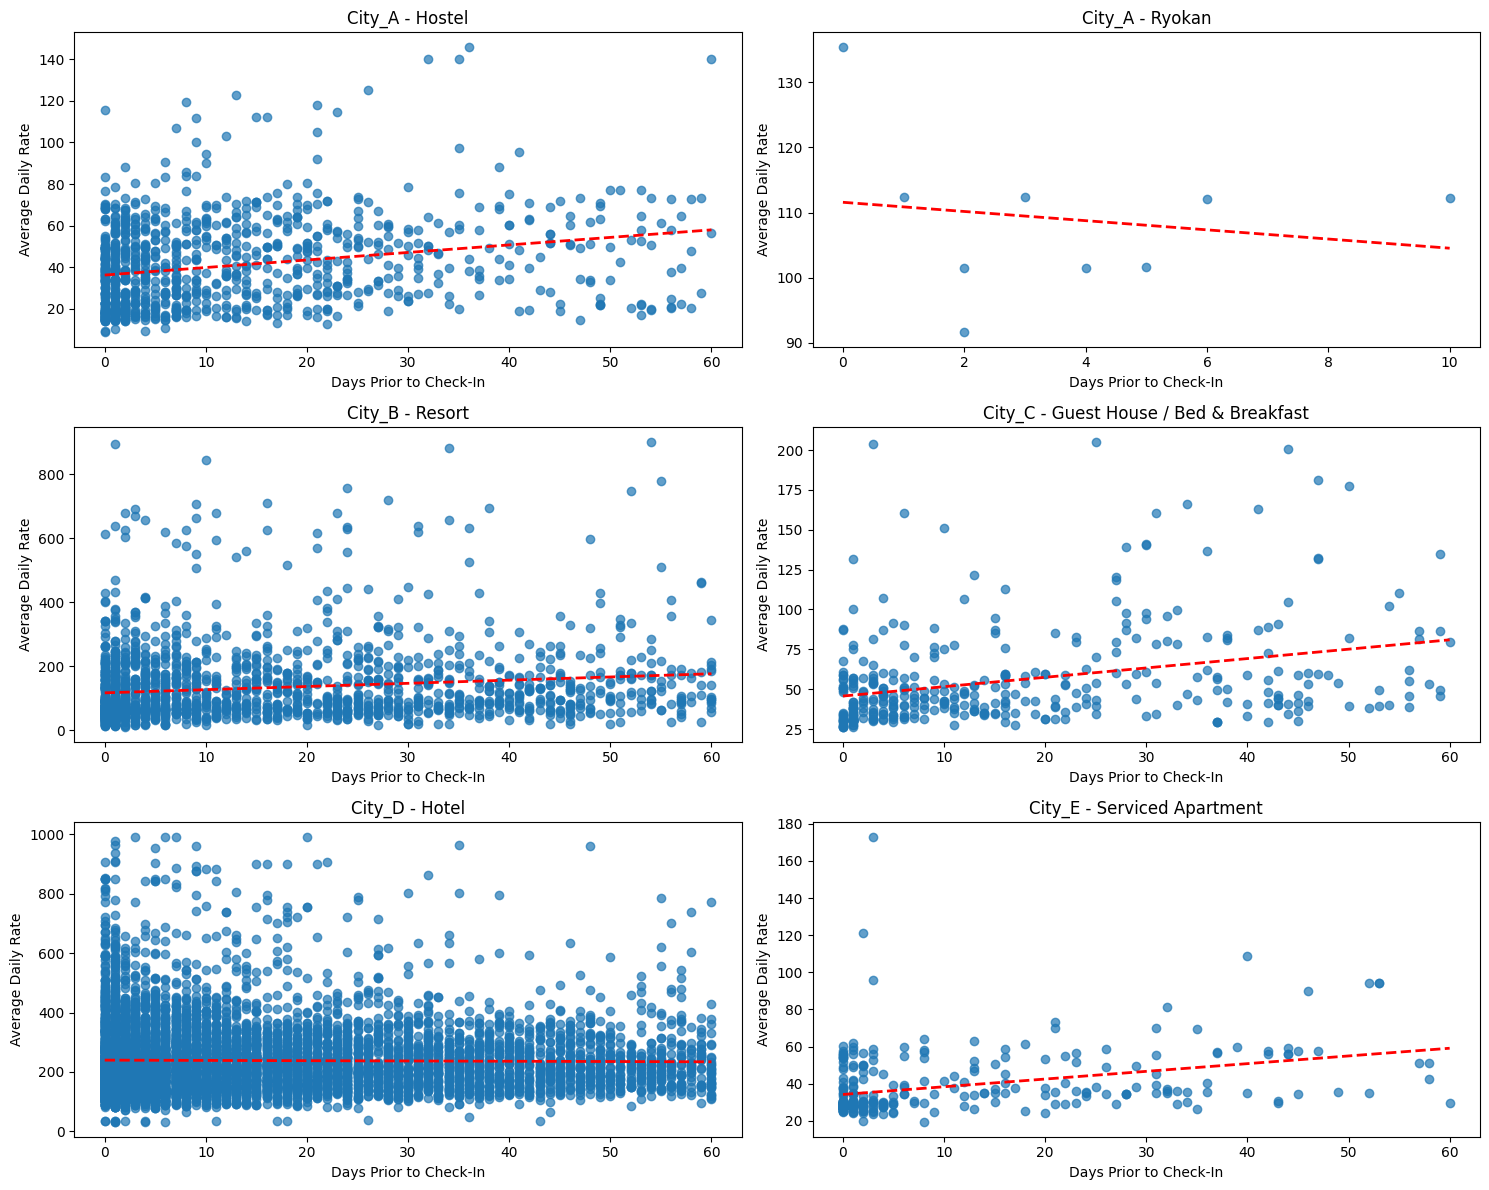

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert 'ADR_USD' to numeric, coercing errors to NaN
df['ADR_USD'] = pd.to_numeric(df['ADR_USD'], errors='coerce')

groups = [
    ("City_A", "Hostel"),
    ("City_A", "Ryokan"),
    ("City_B", "Resort"),
    ("City_C", "Guest House / Bed & Breakfast"),
    ("City_D", "Hotel"),
    ("City_E", "Serviced Apartment")
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for ax, (city, accom) in zip(axes.flatten(), groups):

    temp = df[
        (df["City"] == city) &
        (df["accommadation_type_name"] == accom)
    ].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Clean data for plotting and fitting
    plot_df = temp[['Date_Diff', 'ADR_USD']].dropna()
    x = plot_df["Date_Diff"]
    y = plot_df["ADR_USD"]

    # Debugging print statement
    print(f"Group: {city} - {accom}, Cleaned Data points: {len(x)}")
    if len(x) > 0:
        print(f"  x min: {x.min()}, x max: {x.max()}, x unique count: {x.nunique()}")
    else:
        print(f"  No x data.")

    if len(x) >= 2: # At least two points needed for a line fit
        # Scatter points
        ax.scatter(x, y, alpha=0.7)

        if x.nunique() > 1: # Only try to fit a line if x values are not all the same
            # Trendline
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)

            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, p(x_line), color='red', linestyle="--", linewidth=2)

            ax.set_title(f"{city} - {accom}")
            ax.set_xlabel("Days Prior to Check-In")
            ax.set_ylabel("Average Daily Rate")
        else: # x.nunique() == 1, can't draw a meaningful trendline
            ax.set_title(f"{city} - {accom} (Constant Date_Diff, no trendline)")
            ax.set_xlabel("Days Prior to Check-In")
            ax.set_ylabel("Average Daily Rate")
    elif not x.empty: # If there's some data but not enough for a trendline
        ax.scatter(x, y, alpha=0.7)
        ax.set_title(f"{city} - {accom} (Few data points, no trendline)")
        ax.set_xlabel("Days Prior to Check-In")
        ax.set_ylabel("Average Daily Rate")
    else: # No data at all
        ax.set_title(f"{city} - {accom} (No Data)")
        ax.set_xlabel("Days Prior to Check-In")
        ax.set_ylabel("Average Daily Rate")

# Hide any unused subplots if the number of groups is less than the number of subplots
for i in range(len(groups), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.savefig("booking_trends.png", dpi=300)
plt.show()
# How the "Approach #1 - day with lowest price" is likely computed

# Historical daily rate for each group is averaged and clustered into date_diff groups.

# This suggests something like:

grouped = (
    df.groupby(
        ["City",
         "accommadation_type_name",
         "Date_Diff"]
    )["ADR_USD"]
    .mean()
    .reset_index()
)

# Then find the lowest-price booking window:

lowest = (
    grouped.groupby(
        ["City", "accommadation_type_name"]
    )["ADR_USD"]
    .idxmin()
)

lowest_points = grouped.loc[lowest]

# For the rule:

# lowest price in last 7 days and drop over 5%

# you might calculate:

grouped["prev_rate"] = (
    grouped.groupby(
        ["City",
         "accommadation_type_name"]
    )["ADR_USD"]
    .shift(1)
)

grouped["pct_change"] = (
    grouped["ADR_USD"] -
    grouped["prev_rate"]
) / grouped["prev_rate"] * 100

candidates = grouped[
    (grouped["Date_Diff"] <= 7) &
    (grouped["pct_change"] <= -5)
]

In [47]:
print("Unique Cities:")
print(df['City'].unique())
print("\nUnique Accommodation Types:")
print(df['accommadation_type_name'].unique())

Unique Cities:
['City_A' 'City_B' 'City_C' 'City_D' 'City_E']

Unique Accommodation Types:
['Hotel' 'Serviced Apartment' 'Hostel' 'Guest House / Bed & Breakfast'
 'Motel' 'Resort' 'Apartment' 'Ryokan' 'Resort Villa' 'Private Villa'
 'Bungalow' 'Villa' 'Holiday Park / Caravan Park' 'Capsule Hotel'
 'Love Hotel' 'Home']
